In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

Used Datasets:

https://huggingface.co/datasets/aelhalili/bash-commands-dataset -> 680 rows
https://huggingface.co/datasets/emirkaanozdemr/bash_command_data_6K -> 6.153

In [2]:
dataset = load_dataset("aelhalili/bash-commands-dataset")
dataset

DatasetDict({
    train: Dataset({
        features: ['prompt', 'response'],
        num_rows: 840
    })
})

In [3]:
df = pd.DataFrame(dataset["train"])
df.head()

,prompt,response
0,Move a file called x from the Desktop to the D...,mv ~/Desktop/x ~/Downloads/
1,Open YouTube and search for videos by Mr Beast,xdg-open 'https://www.youtube.com/results?sear...
2,Create a folder named projects inside the Docu...,mkdir ~/Documents/projects
3,Open the Firefox browser,firefox &
4,Search for all PNG files in the Pictures folder,find ~/Pictures -name '*.png'


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   prompt    840 non-null    object
 1   response  840 non-null    object
dtypes: object(2)
memory usage: 13.3+ KB


In [5]:
df.isnull().sum().sort_values()

,0
prompt,0
response,0


<Axes: title={'center': 'Prompt Length and Density Graph'}, ylabel='Density'>

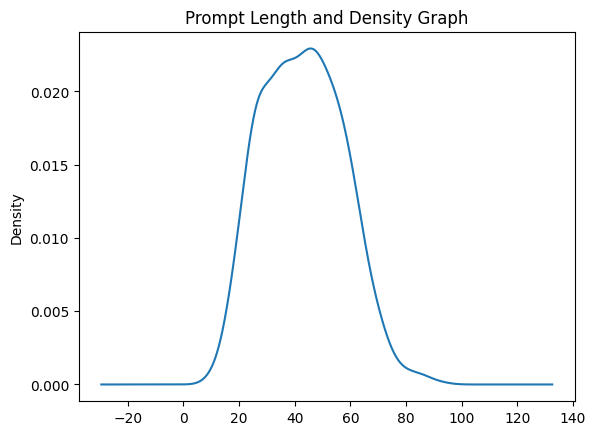

In [6]:
df["prompt_length"] = df["prompt"].apply(len)
df["prompt_length"].plot(kind="kde", title="Prompt Length and Density Graph")

# Data Processing

In [7]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from datasets import Dataset

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [9]:
df = df[df['response'].str.strip() != ""]
df = df[df['prompt'].str.strip() != ""]
df = df[df['prompt'] != df['response']]

In [10]:
slang_dict = {
    r'\bidk\b': 'i do not know',
    r'\bnvm\b': 'nevermind',
    r'\bur\b': 'you are',
    r'\bnah\b': 'no',
    r'\bnaw\b': 'no',
    r'\bok\b': 'okay',
    r'\bsh\*\*\b': 'shit'
}

def clean_and_lemmatize(text):
    text = text.lower().strip()

    for pattern, replacement in slang_dict.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokenlar = word_tokenize(text)

    temiz_tokenlar = [
        lemmatizer.lemmatize(token)
        for token in tokenlar
        if token.isalnum() and token not in stop_words
    ]

    return " ".join(temiz_tokenlar)

In [11]:
df["clean_prompt"] = df["prompt"].apply(clean_and_lemmatize)
df["clean_prompt"].head()

,clean_prompt
0,move file called x desktop downloads directory
1,open youtube search video mr beast
2,create folder named project inside document di...
3,open firefox browser
4,search png file picture folder


In [12]:
df.shape

(840, 4)

In [13]:
def clean_bash_command(command):
    if not isinstance(command, str):
        return ""

    command = command.strip().replace('\n', ' ').replace('\t', ' ')

    command = re.sub(r'\s+', ' ', command)
    return command

In [14]:
df['clean_response'] = df['response'].apply(clean_bash_command)
df["clean_response"]

,clean_response
0,mv ~/Desktop/x ~/Downloads/
1,xdg-open 'https://www.youtube.com/results?sear...
2,mkdir ~/Documents/projects
3,firefox &
4,find ~/Pictures -name '*.png'
...,...
835,sudo systemctl start apache2
836,sudo systemctl enable apache2
837,sudo systemctl stop apache2
838,sudo systemctl restart apache2


convert pd.DataFrame to Datasets.dataset

In [15]:
dataset = Dataset.from_pandas(df[["clean_prompt","clean_response"]])

dataset_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split['train']
val_dataset = dataset_split['test']

# Text Tokenization

In [24]:
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer

In [18]:
model_name = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    inputs = ["translate English to Bash: " + doc for doc in examples["clean_prompt"]]
    targets = [targets for targets in examples["clean_response"]]

    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding=False)

    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding=False)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/168 [00:00<?, ? examples/s]

In [20]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=None)

In [26]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

training_args = Seq2SeqTrainingArguments(
    output_dir="./bash_t5_results",
    eval_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
    logging_steps=100
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [27]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,3.614671
2,No log,3.308028
3,4.098211,3.223755


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=126, training_loss=4.011292048863003, metrics={'train_runtime': 628.3361, 'train_samples_per_second': 3.208, 'train_steps_per_second': 0.201, 'total_flos': 8628039843840.0, 'train_loss': 4.011292048863003, 'epoch': 3.0})

In [29]:
def generate_bash(prompt):
    input_text = "translate English to Bash: " + prompt
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_length=128)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print(generate_bash("Move a file called x from the Desktop to the Downloads directory"))

x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - x - 
